In [1]:
from google.colab import files
uploaded=files.upload()

Saving dataset.csv to dataset.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
# Load dataset
data = pd.read_csv("dataset.csv")

# Display first few rows
print(data.head())

# Extract 2D points
X = data.values

          x         y
0  0.496714  4.861736
1  0.647689  6.523030
2 -0.234153  4.765863
3  1.579213  5.767435
4 -0.469474  5.542560


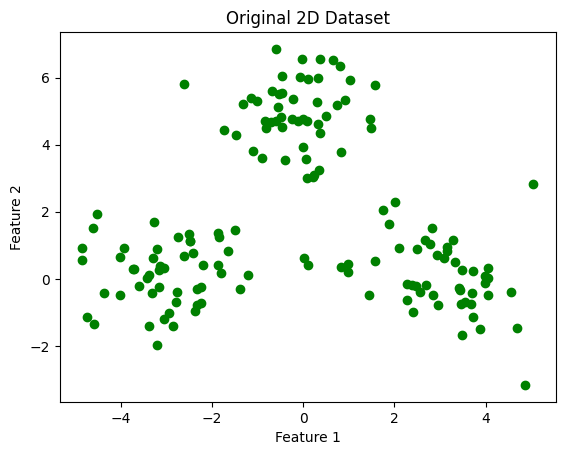

In [13]:
plt.scatter(X[:, 0], X[:, 1], color='green')
plt.title("Original 2D Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

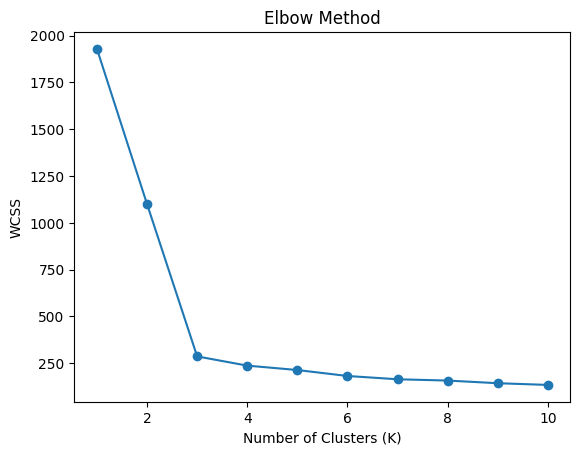

In [15]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [7]:
k = 3  # change this based on elbow graph
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

y_kmeans = kmeans.fit_predict(X)

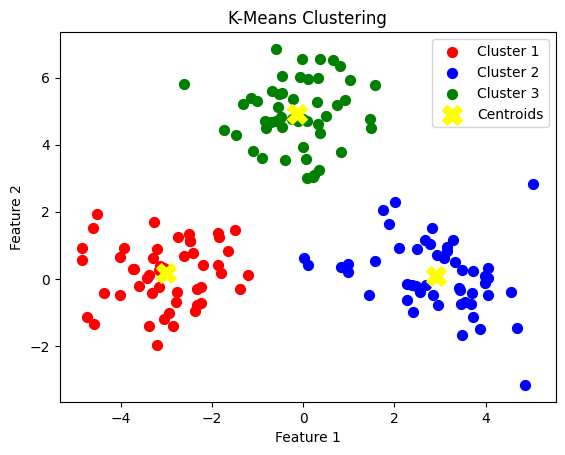

In [8]:
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=50, c=colors[i], label=f'Cluster {i+1}')

# Plot Centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', label='Centroids', marker='X')

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()